# 04. Margin model and playoff odds

This notebook reads the results of `scripts/ml_m4.py` and walks through M4 Phase 2 (`context/ml-m4-method.md`, sections 4 and 5). It covers:

1. The key numbers: a few numbers that sum up the margin model on the development seasons.
2. Why football margins aren't a bell curve, and the key-number shape.
3. Is the spread honest? Calibration of the win chance and of the spread.
4. How the NFL breaks ties, and the check against every real season.
5. Why fixed probabilities make overconfident playoff odds, and how the strength shock fixes it.
6. The 2026 season as of the latest cached data.

It reads saved files only (`data/raw/ml/m4/`), so run `python scripts/ml_m4.py all` first. Everything here uses the development seasons 2006-2019 (and 2002-2025 standings for the tiebreaker check). The 2020-2025 holdout is not touched.

In [1]:
import json
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nflelo").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nflelo.ml import data as D
from nflelo.ml.models import margin as mm
from nflelo.ml.sim import season as sim, tiebreak

plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
pd.set_option("display.width", 160)
INK, ACCENT, MUTED, BAD, MODEL = "#1f2a44", "#2f6fdf", "#9aa3b2", "#d1495b", "#7b4fc9"

M4 = D.ML_DIR / "m4"
margin = json.loads((M4 / "margin_dev.json").read_text())
dev = pd.read_parquet(M4 / "margin_dev.parquet")
tune = json.loads((M4 / "tune.json").read_text())
backtest = json.loads((M4 / "backtest.json").read_text())
rep = pd.read_csv(M4 / "tiebreak_reproduction.csv")
print(f"DEV games: {margin['n']}; frozen shape {mm.CHOSEN_SHAPE}; frozen tau_rest {sim.TAU_REST:g}")

DEV games: 3450; frozen shape keynum; frozen tau_rest 4.5


## 1. The key numbers

The margin model predicts the final score margin (home minus away), not just the winner. Its average is our **spread**. It uses the same three inputs as the win-probability model A4s: Elo, opponent-adjusted efficiency, and the starting-quarterback adjustment. Like M3, it is refit once per season on all earlier seasons from 2001, with older seasons counting less.

In [2]:
c = margin["mae"]
k = margin["shapes"]["keynum"]
rows = {
    "Average miss, model spread (points)": c["model"],
    "Average miss, Elo spread": c["elo"],
    "Average miss, Vegas spread (benchmark)": c["market"],
    "Model minus Elo, with 95% interval": f"{c['model_minus_elo']['diff']:+.3f} [{c['model_minus_elo']['ci_low']:+.3f}, {c['model_minus_elo']['ci_high']:+.3f}]",
    "Typical spread around the forecast, sigma (2019 fit)": margin["coefficients"][-1]["sigma"],
    "Win chance from the margin model, Brier": k["brier"],
    "Win chance from A4s, Brier": margin["A4s"]["brier"],
}
pd.Series(rows, name="DEV 2006-2019").to_frame()

,DEV 2006-2019
"Average miss, model spread (points)",10.667116
"Average miss, Elo spread",10.731078
"Average miss, Vegas spread (benchmark)",10.487391
"Model minus Elo, with 95% interval","-0.064 [-0.118, -0.009]"
"Typical spread around the forecast, sigma (2019 fit)",13.516689
"Win chance from the margin model, Brier",0.215262
"Win chance from A4s, Brier",0.215086


How to read it:

- The model's spread misses the final margin by about 10.7 points on average. That sounds large, but NFL games are noisy: even Vegas misses by about 10.5.
- The model beats Elo's spread by about 0.06 points per game, and the interval excludes zero. That was the acceptance bar.
- Vegas is still better, by about 0.18 points per game.
- The win chance implied by the margin model scores the same as A4s, inside one standard error. For 2026 the site keeps A4s for the win chance anyway, because the live record started with it; the margin model supplies the spread and drives the simulation.

## 2. Football margins aren't a bell curve

A normal curve with the right center and width gets the overall spread of outcomes right. It gets the details wrong: scores come in 3s and 7s, so some margins happen far more often than a smooth curve says, and ties almost never happen. The chart compares how often each margin happened on DEV with what each shape expected, summed over every game.

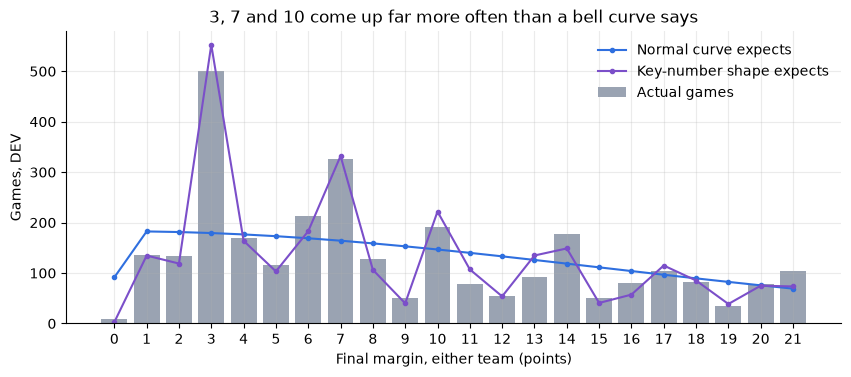

,0,1,3,4,6,7,10,14
actual,9.0,135.0,501.0,170.0,213.0,327.0,191.0,178.0
normal,91.0,183.0,179.0,177.0,169.0,164.0,147.0,119.0
key-number,3.0,135.0,552.0,164.0,183.0,332.0,222.0,149.0


In [3]:
mu, sg, y = dev["mu"].to_numpy(), dev["sigma"].to_numpy(), dev["margin"].to_numpy()
kn = mm.KeyNumbers.from_dict(margin["keynum"])
grid = mm.GRID
exp_n = mm.normal_pmf(mu, sg).sum(axis=0)
exp_k = mm.keynum_pmf(mu, sg, kn).sum(axis=0)
obs = np.array([(np.abs(y) == a).sum() for a in range(22)])
fold = lambda e: np.array([e[np.abs(grid) == a].sum() for a in range(22)])
fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(22)
ax.bar(x, obs, color=MUTED, label="Actual games")
ax.plot(x, fold(exp_n), color=ACCENT, marker="o", ms=3, label="Normal curve expects")
ax.plot(x, fold(exp_k), color=MODEL, marker="o", ms=3, label="Key-number shape expects")
ax.set_xticks(x); ax.set_xlabel("Final margin, either team (points)"); ax.set_ylabel("Games, DEV")
ax.legend(frameon=False); ax.set_title("3, 7 and 10 come up far more often than a bell curve says")
plt.show()
pd.DataFrame({"actual": obs, "normal": fold(exp_n).round(0), "key-number": fold(exp_k).round(0)}, index=x).T.loc[:, [0, 1, 3, 4, 6, 7, 10, 14]]

The key-number shape starts from the normal curve and multiplies each margin by a factor learned on 2001-2005 only (so the development seasons never shaped it). On DEV it scores better on CRPS, a score for whole forecast distributions, by more than one standard error, so the one-SE rule picks it over the simpler normal curve.

In [4]:
r = margin["shape_rule"]
print(f"CRPS: " + ", ".join(f"{k} {v:.4f}" for k, v in margin["crps"].items()))
print(f"{'normal' if r['best'] == 'keynum' else 'keynum'} minus {r['best']}: {r['other_minus_best']['diff']:+.4f} "
      f"(one SE = {r['other_minus_best']['boot_se']:.4f}) -> chosen: {r['chosen']}")
pd.Series(kn.r[:15], index=range(15), name="factor").round(2).to_frame().T

CRPS: normal_continuous 7.6638, normal 7.6620, keynum 7.6480
normal minus keynum: +0.0141 (one SE = 0.0042) -> chosen: keynum


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
factor,0.03,0.69,0.62,2.9,0.87,0.56,1.02,1.9,0.63,0.25,1.42,0.72,0.38,1.01,1.18


## 3. Is the spread honest?

Two checks:

- **Win chance.** The expected calibration error (ECE) measures how far predicted chances sit from what happened. A perfectly calibrated forecaster still shows some ECE from luck, more so with fewer games. So the check compares our ECE with the range a perfect forecaster would show at the same number of games (5th to 95th percentile of simulated draws).
- **Spread.** If our spread is honest, the home team should beat it about half the time, whatever the spread. The table shows each band of predicted spreads with the range a fair coin would give at that many games.

In [5]:
s = margin["shapes"]["keynum"]
print(f"ECE {s['ece']:.4f}; a perfectly calibrated forecaster at n = {s['n']}: {s['ece_null']['p05']:.4f} to {s['ece_null']['p95']:.4f}")
pd.DataFrame(margin["cover_by_bin"]).set_index("bin")[["n", "home_covers", "p05", "p95", "inside"]].round(3)

ECE 0.0141; a perfectly calibrated forecaster at n = 3450: 0.0095 to 0.0249


,n,home_covers,p05,p95,inside
bin,,,,,
"(-inf, -7]",213,0.545,0.441,0.559,True
"(-7, -3]",416,0.524,0.459,0.541,True
"(-3, 0]",573,0.475,0.466,0.534,True
"(0, 3]",689,0.501,0.469,0.531,True
"(3, 7]",825,0.487,0.472,0.528,True
"(7, inf]",734,0.466,0.470,0.530,False


Five of the six bands are inside the coin's range. The exception is big home favorites (our spread above 7): they beat it 46.6% of the time, just under the 47.0% edge of the range. Our spread runs slightly too high there. With six bands checked at a 90% range, one miss is about what luck alone produces, so this is noted rather than acted on.

## 4. How the NFL breaks ties

Playoff odds depend on seeding, and NFL seasons end in ties on record all the time. The rules, in order:

- **Within a division, two teams:** head-to-head record, then division record, record in common games, conference record, strength of victory (the combined record of the teams you beat), strength of schedule, then several points-based steps, and finally a coin toss.
- **Three or more teams in a division:** the same list, using the record among all the tied teams. When a step knocks teams out and two are left, the two start over at step 1 of the two-team list.
- **Wild cards (teams from different divisions):** first keep only the best-ranked team from each division. Then head-to-head (for three or more teams, only if one team beat, or lost to, every other), conference record, common games (at least four), strength of victory, strength of schedule, points, coin toss.
- Only one team wins each application. Everyone else starts over, which matters when a three-way tie leaves two teams.

A real example: in 2015 Denver, New England and Cincinnati all finished 12-4 and won their divisions.

In [6]:
sched = D.load_schedules(range(2015, 2016))
log = []
s = tiebreak.actual_standings(sched, 2015, log)
seeds = s.seeds()
print("AFC seeds:", [s.st.teams[t] for t in seeds["AFC"]])
pd.DataFrame([x for x in log if set(x["group"]) & {"DEN", "NE", "CIN"}])[["kind", "group", "step", "chosen"]]

AFC seeds: ['DEN', 'NE', 'CIN', 'HOU', 'KC', 'PIT']


,kind,group,step,chosen
0,wc,"(NE, CIN, DEN)",sweep,DEN
1,wc,"(NE, CIN)",common4,NE


Denver beat both of the others, so the three-team sweep rule gives Denver the #1 seed. New England and Cincinnati then start over as a two-team tie. They didn't play each other and had the same conference record, so it came down to their record against common opponents, which New England won. That is exactly how the 2015 seeds came out.

**The check against history.** Feeding each real season's results into this code reproduces the actual playoff field and every seed, for all 40 conference-seasons from 2006 to 2025 (and the 8 from 2002 to 2005). The "truth" comes from the playoff bracket itself (who had a bye, who played whom and where) and, where the bracket allows more than one seeding, from the public record of seeds.

In [7]:
print(f"Reproduced: {int(rep['match'].sum())} of {len(rep)} conference-seasons, 2002-2025 "
      f"({int(rep.loc[rep['season'] >= 2006, 'match'].sum())} of {int((rep['season'] >= 2006).sum())} for 2006-2025)")
print(f"Decided by a points-based step or a coin toss: {int((rep['points_or_coin_steps'].fillna('') != '').sum())}")
rep["truth_from"].value_counts().rename("truth from").to_frame()

Reproduced: 48 of 48 conference-seasons, 2002-2025 (40 of 40 for 2006-2025)
Decided by a points-based step or a coin toss: 0


,truth from
truth_from,
public record,33
bracket,15


## 5. Why fixed probabilities make overconfident playoff odds

The simplest simulation plays out the rest of the season thousands of times, using each game's predicted chances. That ignores two things: our ratings are estimates, and teams really do get better or worse as a season goes on. The result is overconfidence: good teams look like near locks too early, bad teams look dead too early.

The fix: in each simulated season, every team gets one random boost or drag, drawn from a normal curve with spread `tau_rest` points, and keeps it all season. Larger `tau_rest` means more humility.

**How tau_rest was chosen.** The first plan tuned it on 2002-2005. That picked 0.5 points, which did nothing on the development seasons, and the odds there stayed overconfident. Walker then decided to tune on the development seasons 2006-2019 instead: simulate from weeks 4, 8, 12 and 16 of each season, score the chance of making the playoffs with the Brier score, and pick the **smallest** tau within one standard error of the best. Since that uses the development seasons, the numbers below are in-sample; the real test is the one pre-registered run on 2020-2025.

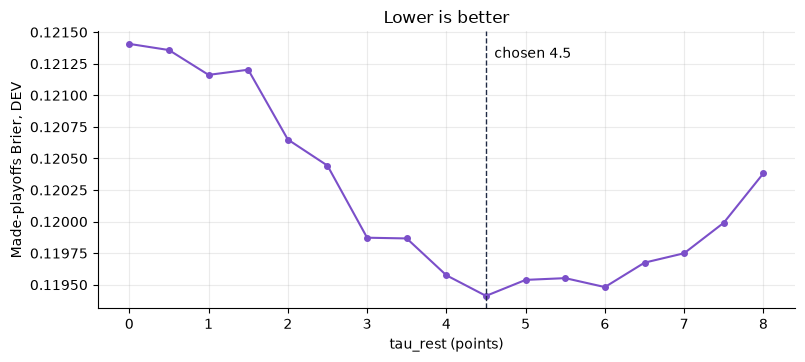

,brier,minus_best,se,within_1se
tau,,,,
0.0,0.12141,0.00200,0.00069,False
0.5,0.12136,0.00195,0.00067,False
1.0,0.12116,0.00175,0.00064,False
1.5,0.12120,0.00179,0.00059,False
2.0,0.12065,0.00124,0.00052,False
2.5,0.12044,0.00103,0.00043,False
3.0,0.11987,0.00046,0.00034,False
3.5,0.11987,0.00045,0.00025,False
4.0,0.11958,0.00016,0.00016,False


In [8]:
t = pd.DataFrame(tune["table"]).set_index("tau")
fig, ax = plt.subplots()
ax.plot(t.index, t["brier"], color=MODEL, marker="o", ms=4)
ax.axvline(tune["chosen"], color=INK, lw=1, ls="--")
ax.annotate(f"chosen {tune['chosen']:g}", (tune["chosen"], t["brier"].max()), xytext=(6, -10), textcoords="offset points")
ax.set_xlabel("tau_rest (points)"); ax.set_ylabel("Made-playoffs Brier, DEV"); ax.set_title("Lower is better")
plt.show()
t.round(5)

The curve is flat between about 4 and 7.5 points: all of those are within one standard error of the best. The rule takes the smallest such value, which here is the best itself, 4.5. (4.0 misses the cut by two millionths of a Brier point, so treat 4 to 7.5 as a tie; the rule just makes the choice mechanical.) A shock of 4.5 points means a typical team's true strength for the rest of the season can sit about a field goal and a half away from where the model has it.

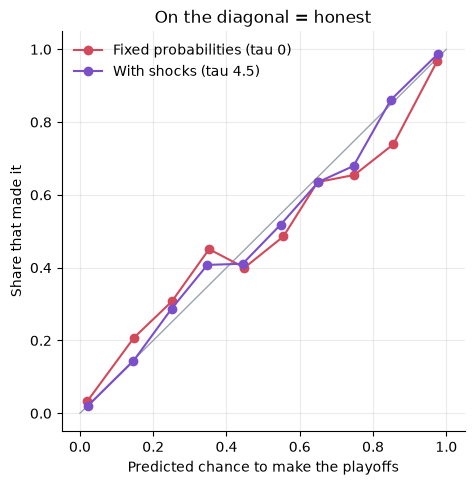

,Brier,"Brier, tau 0",ECE,"ECE, tau 0",null 5%,null 95%,inside
playoffs,0.119541,0.12125,0.018071,0.038638,0.011768,0.027587,True
division,0.088153,0.088016,0.020863,0.016179,0.011227,0.025133,True
seed1,0.031978,0.031681,0.011787,0.009304,0.006368,0.015021,True
reach_sb,0.046529,0.045803,0.014485,0.009717,0.00424,0.01485,True
win_sb,0.028051,0.028254,0.001786,0.006361,0.002203,0.009913,False


In [9]:
rel = pd.DataFrame(backtest["reliability"]); rel0 = pd.DataFrame(backtest["reliability_tau0"])
fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1)
ax.plot(rel0["mean_pred"], rel0["observed"], color=BAD, marker="o", label="Fixed probabilities (tau 0)")
ax.plot(rel["mean_pred"], rel["observed"], color=MODEL, marker="o", label=f"With shocks (tau {backtest['tau_rest']:g})")
ax.set_xlabel("Predicted chance to make the playoffs"); ax.set_ylabel("Share that made it")
ax.legend(frameon=False, loc="upper left"); ax.set_title("On the diagonal = honest")
plt.show()
m = pd.DataFrame({k: {"Brier": v["brier"], "Brier, tau 0": v["brier_tau0"], "ECE": v["ece"], "ECE, tau 0": v["ece_tau0"],
                      "null 5%": v["ece_null"]["p05"], "null 95%": v["ece_null"]["p95"], "inside": v["ece_in_null_range"]}
                  for k, v in backtest["metrics"].items()}).T
m

Below the diagonal on the right means overconfidence: with fixed probabilities, teams given 80-90% made the playoffs only 74% of the time. The shocks pull the curve back toward the diagonal (86% in that band), the made-playoffs ECE drops from 0.042 to 0.018, inside the range a perfect forecaster would show, and the Brier score improves by 0.0017. The other outcomes stay about level. Won-Super-Bowl ECE sits just under its range: that is "too good to be luck", not miscalibration, because almost every Super Bowl chance is near zero. Because tau was tuned on these same seasons, treat all of this as a description; the pre-registered 2020-2025 run is the test.

In [10]:
pd.DataFrame(backtest["per_week"]).set_index("week").round(4)

,n,brier,brier_tau0,ece
week,,,,
4,448,0.1732,0.1764,0.0427
8,448,0.1383,0.1398,0.0321
12,448,0.1041,0.1056,0.0314
16,448,0.0625,0.0632,0.0260


Early in the season (week 4) there is the most uncertainty left, so that is where overconfidence costs the most and where the shocks matter most.

## 6. The 2026 season now

The same simulation, as of the latest cached nflverse data, with the frozen settings (5,000 seasons here to keep the notebook quick; the weekly job runs 20,000). These odds are recorded every week in `experiments/live/sim_2026.csv` but stay off the site until the sign-off (`experiments/live/publish.json`).

In [11]:
import json as _json
from nflelo import data as elo_data
from nflelo.ml import asof, live, live_features
from nflelo.ml.sim import state

m26 = _json.loads((live.LIVE_DIR / "margin_2026.json").read_text())
fit, kn26 = mm.MarginFit.from_dict(m26["fit"]), (mm.KeyNumbers.from_dict(m26["keynum"]) if m26["keynum"] else None)
years = range(1999, 2027)
pbp = D.load_pbp(years, columns=["game_id", "posteam", "defteam", "play_type", "pass", "rush", "epa", "success", "wp",
                                 "two_point_attempt", "qb_dropback", "passer_id", "play_id"])
sch = asof.add_asof(D.load_schedules(years))
games = elo_data.load_games()
now = sch.loc[sch["home_score"].notna() & (sch["season"] == 2026), "kickoff"].max() + pd.Timedelta(hours=4)
played = games[pd.to_datetime(games["date"]) <= now.tz_convert("America/New_York").tz_localize(None)]
inp, feats, adj = state.state_at(pbp, sch, played[played["home_score"].notna()], 2026, now, fit, m26["shape"], kn26)
odds = sim.simulate(inp, 5000, tau=sim.TAU_REST, seed=20261004)
print(f"as of {now:%Y-%m-%d %H:%M %Z}; {int(inp.remaining.sum())} games left")
odds.sort_values("playoffs", ascending=False).round(3)

as of 2026-10-04 13:30 EDT; 222 games left


,playoffs,division,seed1,reach_sb,win_sb,wins_mean,wins_p10,wins_p90
team,,,,,,,,
SF,0.874,0.537,0.319,0.235,0.130,11.935,9.0,15.0
BUF,0.871,0.716,0.288,0.208,0.109,11.792,9.0,15.0
MIN,0.819,0.511,0.217,0.139,0.070,11.241,8.0,14.0
JAX,0.803,0.671,0.150,0.156,0.079,11.070,8.0,14.0
SEA,0.790,0.349,0.166,0.197,0.112,11.019,8.0,14.0
KC,0.705,0.407,0.127,0.106,0.048,10.440,7.0,14.0
DEN,0.651,0.325,0.097,0.106,0.056,10.132,7.0,13.0
PHI,0.635,0.568,0.060,0.070,0.032,9.494,6.0,13.0
DET,0.626,0.270,0.081,0.071,0.038,9.951,7.0,13.0
